<a href="https://colab.research.google.com/github/GopalSir/snnTorchTutorials/blob/main/tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 6.6 MB/s eta 0:00:00


In [2]:
import snntorch as snn
import torch

In [3]:
batch_size = 128
data_path = '/tmp/data/mnist'
num_classes = 10

dtype = torch.float

In [4]:
from torchvision import datasets, transforms

#Define a transform
transform = transforms.Compose(
    [transforms.Resize((28,28)),
     transforms.Grayscale(),
     transforms.ToTensor(),
     transforms.Normalize((0,),(1,))]
)

mnist_train = datasets.MNIST(data_path,train=True,download=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.35MB/s]


In [5]:
from snntorch import utils

In [6]:
subset = 10
mnist_train = utils.data_subset(mnist_train,subset)

In [7]:
type(mnist_train)

torchvision.datasets.mnist.MNIST

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(mnist_train, batch_size = batch_size, shuffle=True)

In [20]:
num_steps = 1000
raw_vector = torch.ones(num_steps)*0.5

In [21]:
print("hello word")

hello word


In [22]:
from snntorch import spikegen

# Iterate through minibatches
data = iter(train_loader)
data_it, targets_it = next(data)

# Spiking Data
spike_data = spikegen.rate(data_it, num_steps=num_steps)

In [23]:
import matplotlib.pyplot as plt
import snntorch.spikeplot as splt
from IPython.display import HTML

In [24]:
spike_data_sample = spike_data[:, 0, 0]
print(spike_data_sample.size())

torch.Size([1000, 28, 28])


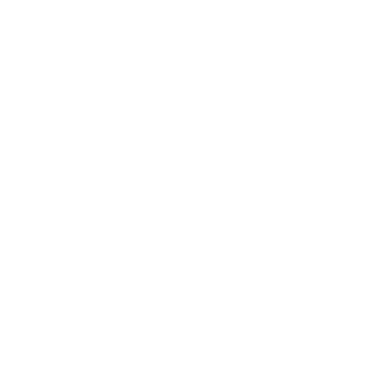

In [25]:
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample, fig, ax)
# plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'

HTML(anim.to_html5_video())